# Solver demo + grid-convergence study, vertification using Hertz theory

This notebook runs the `gpu_ehl` solver directly from Python for a single impact
$(\mathrm{St}=100,\, n=4)$ and studies how the numerical solution converges as
the radial grid is refined. 

A heads up: the heaviest case, $N_r=3000$ with $N_t=10000$, should take
about **15 minutes** on a single CPU core — this is precisely why we needed GPU acceleration for the parametric sweep.

At the end of the notebook, we upload precomputed data from the case $n=2$ and compare to the analytical solution 
(following V.Bertin's JFM 2024) to validate the numerical solutions.

Joaquin Garcia-Suarez (joquin.garciasuarez@epfl.ch), 2026.



In [60]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import time
from pathlib import Path

import jax
jax.config.update("jax_platform_name", "cpu")
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

from gpu_ehl.geometry import make_radial_grid, make_time_grid
from gpu_ehl.elasticity import load_or_build_kernel
from gpu_ehl.solver import simulate_single_setup
from gpu_ehl.io import save_results_h5

# Common parameters
STOKES = 100.0
EXPONENT = 4.0
LR = 6.0
DELTA_T = 0.5e-3
NT = 10000
NT_INI = 200
NUM_SNAPSHOTS = 100

# Cache directory for this notebook
cache_dir = Path.home() / ".cache" / "gpu-ehl" / "notebook_03"
cache_dir.mkdir(parents=True, exist_ok=True)
print("Cache:", cache_dir)


Cache: /home/aj/.cache/gpu-ehl/notebook_03


In [44]:
def case_cache_file(nr: int) -> Path:
    """Return the HDF5 cache path for a given spatial resolution."""
    return cache_dir / f"St{STOKES:.0f}_n{EXPONENT:.0f}_NR{nr}_NT{NT}.h5"


def load_case(cache: Path):
    """Load a cached simulation into a flat dictionary."""
    with h5py.File(cache, "r") as f:
        r = f["r_grid"][:]
        time_grid = f["time_grid"][:]

        # Locate the single case group saved by save_results_h5
        case = None
        for sk in f:
            if sk.startswith("Stokes_"):
                for shk in f[sk]:
                    if shk.startswith("Shape_"):
                        case = f[sk][shk]
                        break
                if case is not None:
                    break

        steps = (time_grid.shape[0] - 1) // NUM_SNAPSHOTS
        t_snap = np.arange(1, NUM_SNAPSHOTS + 1) * steps * DELTA_T

        return {
            "r": r,
            "t": t_snap,
            "V": case["V"][:],
            "Force": case["Force"][:],
            "Central_h": case["Central_h"][:],
            "D": case["D_snapshots"][:],
            "w": case["w_snapshots"][:],
            "p": case["p_snapshots"][:],
            "E_elastic": case["E_elastic"][:],
        }


def run_case(nr: int, force: bool = False):
    """Run a simulation, reusing a cached HDF5 file when available."""
    cache = case_cache_file(nr)
    if not force and cache.exists():
        print(f"Loading cached NR={nr}")
        data = load_case(cache)
        data["elapsed"] = 0.0
        return data

    print(f"Running NR={nr} (this may take a few minutes)...")
    r = make_radial_grid(nr, LR)
    dr = float(r[1] - r[0])
    kernel = load_or_build_kernel(nr, LR)
    Time = make_time_grid(DELTA_T, NT, NT_INI)[1]

    t0 = time.time()
    history = simulate_single_setup(
        stokes=STOKES,
        exponent=EXPONENT,
        KernelMatrix=kernel,
        r=r,
        delta_t=DELTA_T,
        dr=dr,
        nt=NT,
        nt_ini=NT_INI,
        num_snapshots=NUM_SNAPSHOTS,
    )
    history = jax.block_until_ready(history)
    elapsed = time.time() - t0

    S_flat = jnp.array([STOKES], dtype=jnp.float32)
    E_flat = jnp.array([EXPONENT], dtype=jnp.float32)
    save_results_h5(cache, history, r, Time, S_flat, E_flat, num_snapshots=NUM_SNAPSHOTS)

    data = load_case(cache)
    data["elapsed"] = elapsed
    print(f"NR={nr} finished in {elapsed:.1f}s")
    return data


## Reference simulation

Run the finest spatial resolution ($N_r=3000$) once. This is the reference
solution used for the convergence plots below. The restitution coefficient is
computed as

$$
e = \left|\frac{V(t_{\rm final})}{V(t_{\rm init})}\right|,
$$

where $V(t)$ is the indenter velocity recorded during the dynamic phase.


In [45]:
ref_nr = 3000
ref = run_case(ref_nr)
print(f"Reference NR={ref_nr} loaded.")
print(f"Initial velocity  : {ref['V'][0]:.6f}")
print(f"Rebound velocity  : {ref['V'][-1]:.6f}")
print(f"Wall-clock time   : {ref['elapsed']:.1f}s")

Loading cached NR=3000
Reference NR=3000 loaded.
Initial velocity  : -0.999869
Rebound velocity  : 0.904933
Wall-clock time   : 0.0s


## Scalar observables

For each grid resolution we extract three quantities:

- restitution coefficient $e$,
- minimum central gap $h_{\min}$,
- peak impact force $F_{\max}$.


In [46]:
def compute_metrics(data: dict, n: float) -> dict:
    """Compute scalar observables from a simulation dictionary."""
    V = data["V"]
    Force = data["Force"]
    r = data["r"]
    D = data["D"]
    w = data["w"]

    e = float(np.abs(V[-1] / V[0]))
    F_max = float(Force.max())
    gap = D[:, None] + 0.5 * r ** n - w
    h_min = float(gap.min())
    return {"e": e, "F_max": F_max, "h_min": h_min}


# Run all resolutions
resolutions = [300, 600, 1200, 1800, 2400, 3000]
results = {}
for nr in resolutions:
    data = run_case(nr)
    results[nr] = {"data": data, "metrics": compute_metrics(data, EXPONENT)}


Loading cached NR=300
Loading cached NR=600
Loading cached NR=1200
Loading cached NR=1800
Loading cached NR=2400
Loading cached NR=3000


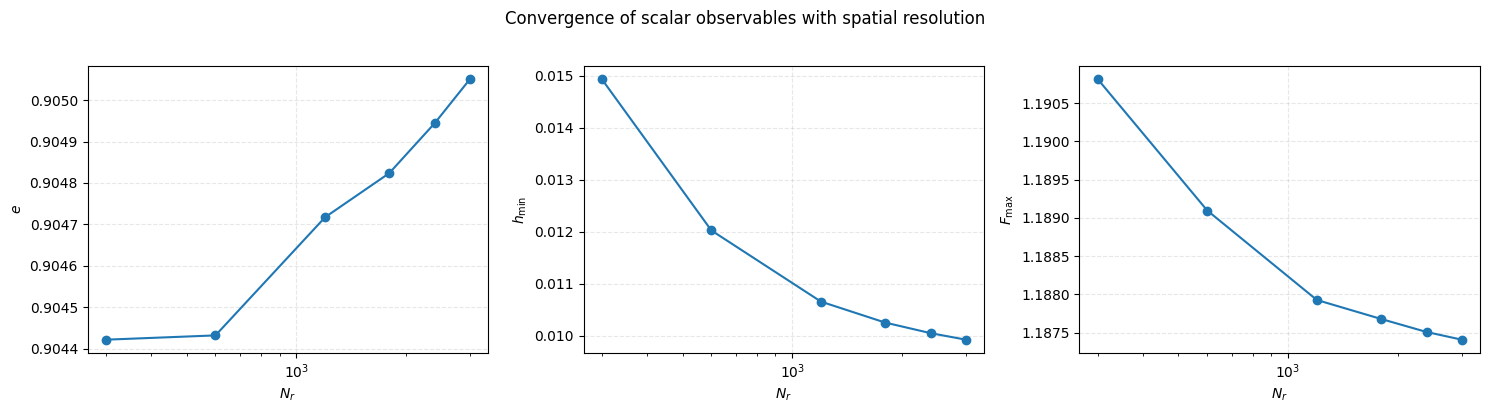

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ["e", "h_min", "F_max"]
labels = [r"$e$", r"$h_{\min}$", r"$F_{\max}$"]

for ax, m, lab in zip(axes, metrics, labels):
    vals = [results[nr]["metrics"][m] for nr in resolutions]
    ax.plot(resolutions, vals, "o-", color="tab:blue")
    ax.set_xlabel(r"$N_r$")
    ax.set_ylabel(lab)
    ax.set_xscale("log")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Convergence of scalar observables with spatial resolution", y=1.02)
plt.tight_layout()
plt.show()

## Relative error against the $N_r=3000$ reference

Denoting the reference value by $q(3000)$, the relative error for a coarser
grid is

$$
\begin{align}
\epsilon_e(N_r) &= \left|\frac{e(N_r) - e(3000)}{e(3000)}\right|, \\
\epsilon_{h_{\min}}(N_r) &= \left|\frac{h_{\min}(N_r) - h_{\min}(3000)}{h_{\min}(3000)}\right|, \\
\epsilon_{F_{\max}}(N_r) &= \left|\frac{F_{\max}(N_r) - F_{\max}(3000)}{F_{\max}(3000)}\right|.
\end{align}
$$

A first-order method gives a slope of $1$ on a log-log plot versus $1/N_r$.


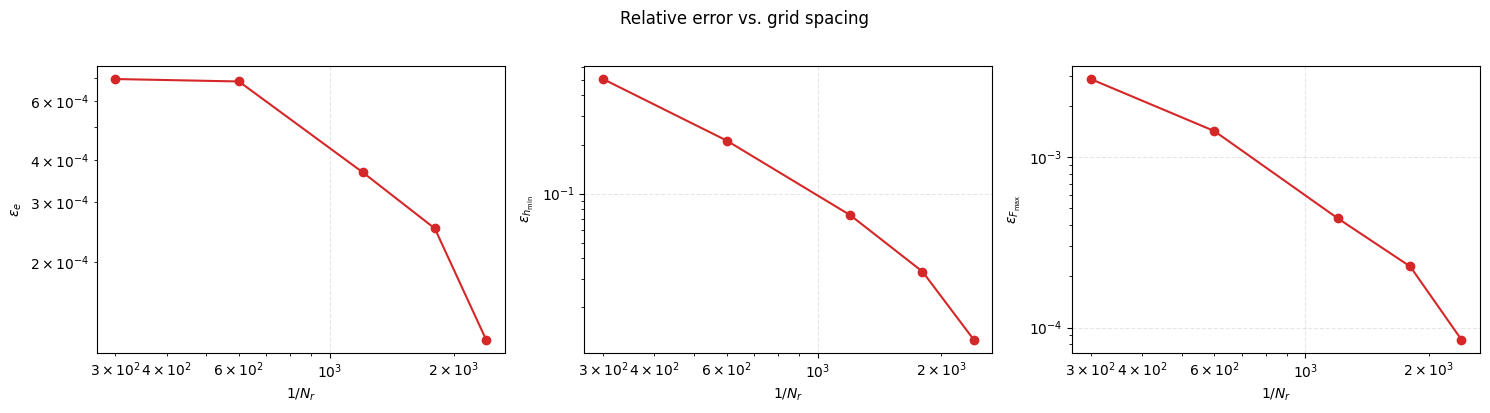

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ref = results[3000]["metrics"]
coarse_resolutions = [nr for nr in resolutions if nr != 3000]
inv_nr = 1.0 / np.array(coarse_resolutions)
nr = np.array(coarse_resolutions)

for ax, m, lab in zip(axes, metrics, labels):
    errs = [
        abs(results[nr]["metrics"][m] - ref[m]) / abs(ref[m])
        for nr in coarse_resolutions
    ]
    ax.plot(nr, errs, "o-", color="tab:red")
    ax.set_xlabel(r"$1/N_r$")
    ax.set_ylabel(r"$\epsilon_{" + lab.strip("$") + r"}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Relative error vs. grid spacing", y=1.02)
plt.tight_layout()
plt.show()

## Time history for the reference case

Gap $D(t)$, velocity $V(t)$, and force $F(t)$ during the dynamic phase. The
velocity changes sign at the rebound; the force peaks shortly before maximum
compression.


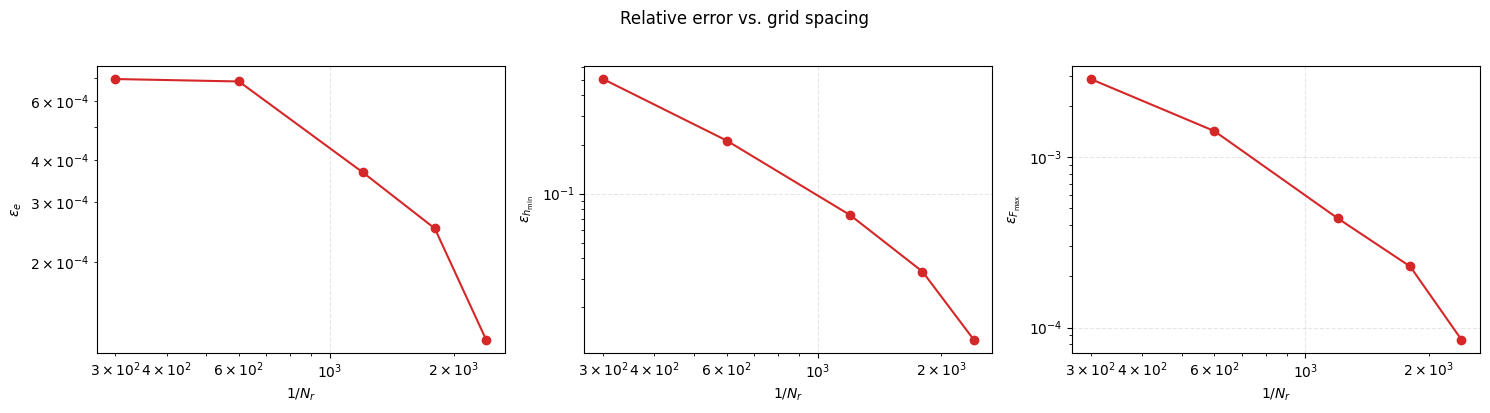

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ref_metrics = results[3000]["metrics"]          # <-- renamed from ref
coarse_resolutions = [nr for nr in resolutions if nr != 3000]

for ax, m, lab in zip(axes, metrics, labels):
    errs = [
        abs(results[nr]["metrics"][m] - ref_metrics[m]) / abs(ref_metrics[m])  # <-- updated
        for nr in coarse_resolutions
    ]
    ax.plot(nr, errs, "o-", color="tab:red")
    ax.set_xlabel(r"$1/N_r$")
    ax.set_ylabel(r"$\epsilon_{" + lab.strip("$") + r"}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Relative error vs. grid spacing", y=1.02)
plt.tight_layout()
plt.show()

## Deformed leading edge and pressure profile

Profiles at the instant of maximum approach (minimum central gap) for every
resolution. Overlaying the curves shows how the near-contact region converges as
$N_r$ increases. The gap is

$$
h(r) = D + \frac{1}{2} r^n - w(r),
$$

and $p(r)$ is the lubrication pressure.


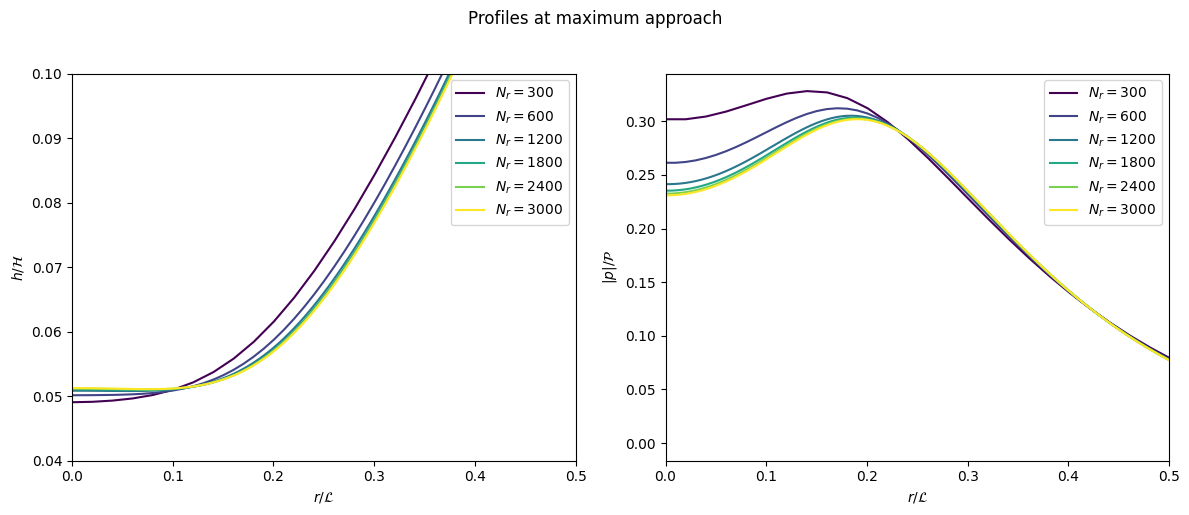

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(resolutions)))

for nr, col in zip(resolutions, colors):
    d = results[nr]["data"]
    idx = int(np.argmin(d["Central_h"]))
    h = d["D"][idx] + 0.5 * d["r"] ** EXPONENT - d["w"][idx]

    axes[0].plot(d["r"], h, color=col, label=f"$N_r={nr}$")
    axes[1].plot(d["r"], -d["p"][idx], color=col, label=f"$N_r={nr}$")

axes[0].set_xlim(0.0, 0.5)
axes[0].set_ylim(0.04, 0.1)
axes[0].set_xlabel(r"$r/\mathcal{L}$")
axes[0].set_ylabel(r"$h/\mathcal{H}$")
axes[0].legend(frameon=True)

axes[1].set_xlim(0.0, 0.5)
axes[1].set_xlabel(r"$r/\mathcal{L}$")
axes[1].set_ylabel(r"$|p|/\mathcal{P}$")
axes[1].legend(frameon=True)

plt.suptitle("Profiles at maximum approach", y=1.02)
plt.tight_layout()
plt.show()

## Why GPU? 

*Now it is evident...*

The wall-clock times below were measured while running this notebook. The
finest case already costs $ \sim 15$ minutes on a single CPU, and the full paper
study spans $13 \times 10 = 130$ such simulations. That is the practical
motivation for the JAX/GPU pipeline used in the paper: the same workload runs in
a few minutes on one NVIDIA H100 GPU.


### Same thing from the command line

The single-case run can also be launched without writing Python:

```bash
jax-ehl single --stokes 100 --exponent 4.0 --output result.h5
```

The CLI uses the same solver API shown above and writes a standard HDF5 file
that can be loaded with `gpu_ehl.io.load_results_h5`.


This notebook caches its simulations in
`~/.cache/gpu-ehl/notebook_03/`, so re-running it only computes missing
resolutions. Delete that directory if you really want to force a fully-fresh run.
